# ML - Thyroid Cancer Recurrance Prediction
In this project I aim to reproduce the machine learning workflow used in a published study on predicting thyroid cancer recurrence in patients diagnosed with well differentiated thyroid cancer.  

**Reference Article**: https://link.springer.com/article/10.1007/s00405-023-08299-w#Sec7

In [1]:
import sys
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(ROOT)

os.getcwd()

'c:\\Users\\daniy\\OneDrive\\Escritorio\\personal_projects\\ml-thyroid-cancer-recurrance\\notebooks'

# Library Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')

# Install and import dataset

In [16]:
from src.load_data import load_thyroid_data
from pprint import pprint

X, y, metadata = load_thyroid_data()

# metadata
pprint(metadata)

# Unite dataset for EDA
df = pd.concat([X, y], axis=1)


{'abstract': 'This data set contains 13 clinicopathologic features aiming to '
             'predict recurrence of well differentiated thyroid cancer. The '
             'data set was collected in duration of 15 years and each patient '
             'was followed for at least 10 years.',
 'additional_info': {'citation': 'Please cite the original article if you use '
                                 'the data set for secondary research and '
                                 'public demonstrations:\n'
                                 'https://doi.org/10.1007/s00405-023-08299-w',
                     'funded_by': 'No funding was provided.',
                     'instances_represent': 'Individual patients',
                     'preprocessing_description': None,
                     'purpose': 'It was a part of research in the field of AI '
                                'and Medicine',
                     'recommended_data_splits': 'No',
                     'sensitive_data': 'No',
    

# EDA

In [4]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [5]:
print(df.shape)
df.nunique()

(383, 17)


Age                     65
Gender                   2
Smoking                  2
Hx Smoking               2
Hx Radiothreapy          2
Thyroid Function         5
Physical Examination     5
Adenopathy               6
Pathology                4
Focality                 2
Risk                     3
T                        7
N                        3
M                        2
Stage                    5
Response                 4
Recurred                 2
dtype: int64

In [6]:
# Check missing values
df.isnull().sum()

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64

Dataset has 383 lines and 17 columns. There is no missing values. All categorical variables have low cardinality.

In [7]:
# Age distribution
df["Age"].describe()

count    383.000000
mean      40.866841
std       15.134494
min       15.000000
25%       29.000000
50%       37.000000
75%       51.000000
max       82.000000
Name: Age, dtype: float64

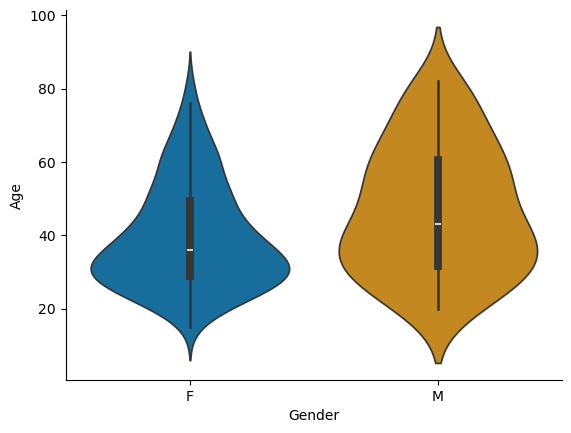

In [8]:
# Age distribution by Gender
df.groupby("Gender")["Age"].describe()
sns.violinplot(data=df, x="Gender", y="Age", palette="colorblind")
sns.despine()
plt.show()

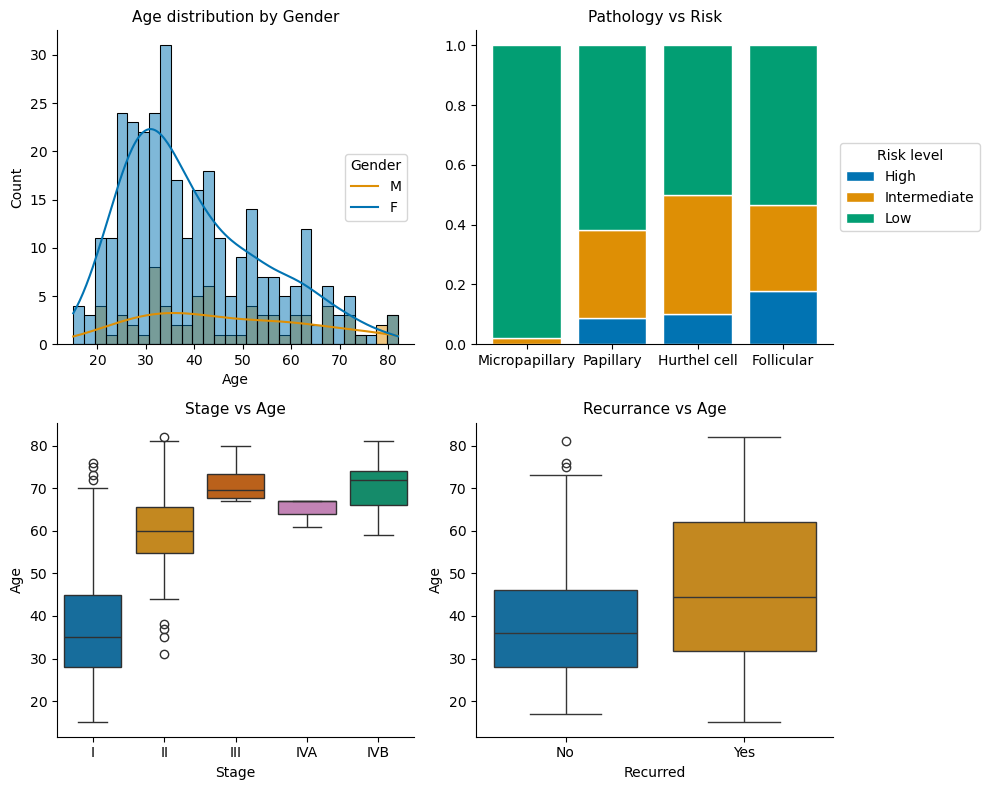

In [9]:
# Figures
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


# Age
sns.histplot(data=df, x="Age", kde=True, hue="Gender", bins=30, ax=axes[0, 0], palette="colorblind")

axes[0, 0].set_title('Age distribution by Gender', fontsize=11)

axes[0, 0].legend(
    title="Gender",
    labels = ("M", "F"),
    loc="center right"
)

# Pathology vs Risk proportions
prop = (
    df.groupby("Pathology")["Risk"]
      .value_counts(normalize=True)
      .rename("risk_prop")
      .reset_index()
)

pivot = prop.pivot(index="Pathology", columns="Risk", values="risk_prop").fillna(0)
pivot = pivot.reindex(["Micropapillary", "Papillary", "Hurthel cell", "Follicular"])

groups = pivot.index # Pthology
categories = pivot.columns # Risk levels

palette = sns.color_palette("colorblind")
bottom = [0] * len(groups)

for cat, color in zip(categories, palette):
    values = pivot[cat].values
    axes[0, 1].bar(groups, values, bottom=bottom, color=color, edgecolor="white", label=cat)
    bottom = [b + v for b, v in zip(bottom, values)]

axes[0, 1].set_title('Pathology vs Risk', fontsize=11)

axes[0, 1].legend(
    title="Risk level",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

# Stage vs Age
order=["I", "II", "III", "IVA", "IVB"]
sns.boxplot(data=df, x="Stage", y="Age", hue="Stage", ax=axes[1, 0], palette="colorblind", order=order)

axes[1, 0].set_title('Stage vs Age', fontsize=11)

# Recurrance vs Age
sns.boxplot(data=df, x="Recurred", y="Age", hue="Recurred", ax=axes[1, 1], palette="colorblind")

axes[1, 1].set_title('Recurrance vs Age', fontsize=11)

# Plot
sns.despine()
plt.tight_layout()
plt.show()



There are more female than male patients, with similar age distributions across genders. Higher ATA risk is more common within Follicular and Hürthle cell cancer types. Cancer stage shows a positive association with age, with more advanced stages appearing in older patients. Thyroid cancer recurrence is also more frequent among older patients.

# Model training

...

In [10]:
from src.training import train_models
best_models, X_test, y_test = train_models(X, y, cv=5)

for model in best_models:
    print(f"\nModel: {model}:")
    print(f"Best parameters: {best_models[model]['best_params']}")
    print(f"CV score: {best_models[model]['cv_score']}")


Training KNN...
Training RF...
Training SVM...

Model: KNN:
Best parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'distance'}
CV score: 0.9280803807509252

Model: RandomForest:
Best parameters: {'rf__max_depth': 10, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
CV score: 0.9575356953992596

Model: SVM:
Best parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
CV score: 0.9509783183500794


# Model evaluation

...

In [11]:
from src.evaluation import compare_models

results_df, conf_mats, reports = compare_models(best_models, X_test, y_test)

print("Model comparison results:")
print("\nConfusion Matrices:")
for model, conf_mat in conf_mats.items():
    print(f"{model}:\n{conf_mat}\n")
print("\nClassification Reports:")
for model, report in reports.items():
    print(f"{model}:\n{report}\n")
print("\nSummary:")
print(results_df)

Model comparison results:

Confusion Matrices:
KNN:
[[56  2]
 [ 4 15]]

RandomForest:
[[58  0]
 [ 1 18]]

SVM:
[[58  0]
 [ 3 16]]


Classification Reports:
KNN:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95        58
         Yes       0.88      0.79      0.83        19

    accuracy                           0.92        77
   macro avg       0.91      0.88      0.89        77
weighted avg       0.92      0.92      0.92        77


RandomForest:
              precision    recall  f1-score   support

          No       0.98      1.00      0.99        58
         Yes       1.00      0.95      0.97        19

    accuracy                           0.99        77
   macro avg       0.99      0.97      0.98        77
weighted avg       0.99      0.99      0.99        77


SVM:
              precision    recall  f1-score   support

          No       0.95      1.00      0.97        58
         Yes       1.00      0.84      0.91        19

